In [ ]:
!pip install pyspark -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("WeatherWear-EDA").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Ready")

Ready


In [ ]:
C:\Users\aditi\Documents\WeatherWear\data\processed\merged_dataset.parquet

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ._SUCCESS.crc to ._SUCCESS.crc
Saving .part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet.crc to .part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet.crc
Saving _SUCCESS to _SUCCESS
Saving part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet to part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet


In [ ]:
import os
for root, dirs, files in os.walk('/content'):
    for file in files:
        if 'parquet' in file or 'parquet' in root:
            print(os.path.join(root, file))

/content/part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet
/content/.part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet.crc


In [ ]:
df = spark.read.parquet('/content/part-00000-a617817b-2eed-4b91-a0cd-52ae6cc0451d-c000.snappy.parquet').toPandas()
print(df.shape)
print(df.columns.tolist())
df.head()

(1200, 15)
['city', 'year', 'month', 'season', 'clothing_category', 'avg_temperature', 'avg_precipitation', 'avg_windspeed', 'avg_humidity', 'avg_uv_index', 'avg_rating', 'review_count', 'review_demand_score', 'demand_score_norm', 'price']


,city,year,month,season,clothing_category,avg_temperature,avg_precipitation,avg_windspeed,avg_humidity,avg_uv_index,avg_rating,review_count,review_demand_score,demand_score_norm,price
0,Berlin,2019,1,3,Layered clothing,1.114516,0.091398,16.492092,83.364968,NaN,4.423729,59.0,0.0054,NaN,NaN
1,Berlin,2019,2,3,Heavy outerwear,4.029315,0.042113,14.316029,77.695263,NaN,4.578947,38.0,0.0034,NaN,NaN
2,Berlin,2019,3,0,Heavy outerwear,6.867137,0.093683,17.878948,76.573161,NaN,4.507692,65.0,0.0059,NaN,NaN
3,Berlin,2019,4,0,Heavy outerwear,10.648542,0.021111,14.444947,60.096928,NaN,4.788462,52.0,0.0047,NaN,NaN
4,Berlin,2019,5,0,Layered clothing,12.675806,0.055511,13.792759,65.904094,NaN,4.378378,37.0,0.0034,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
fig_size = (12, 5)

1. MISSING VALUES
                     Missing Count  Missing %
avg_uv_index                  1200      100.0
avg_rating                     180       15.0
review_count                   180       15.0
review_demand_score            180       15.0
demand_score_norm             1200      100.0
price                         1200      100.0


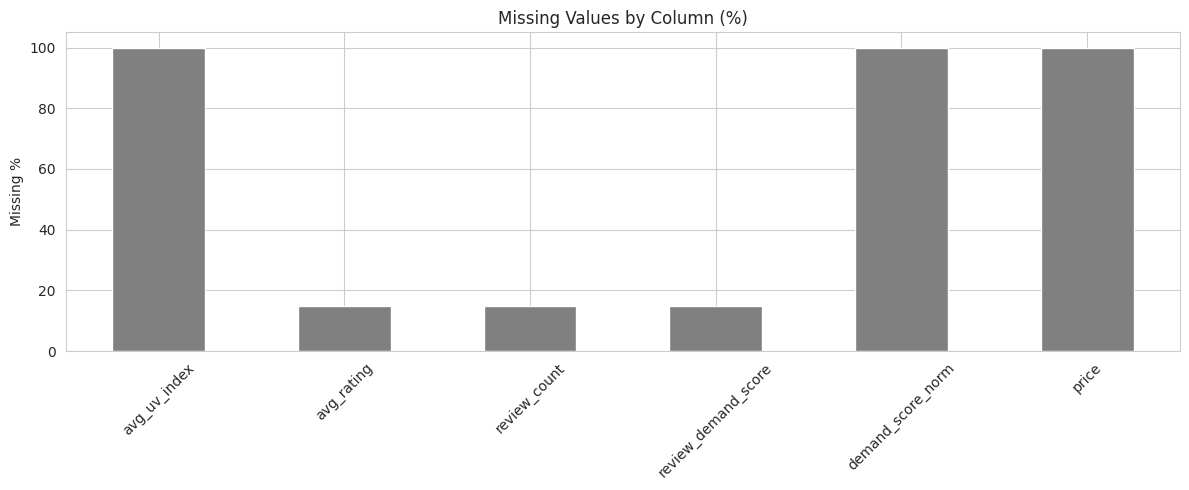

In [ ]:
#1. Missing Values
print("=" * 50)
print("1. MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])
plt.figure(figsize=fig_size)
missing_pct[missing_pct > 0].plot(kind="bar", color="gray")
plt.title("Missing Values by Column (%)")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2. TEMPERATURE DISTRIBUTION
count    1200.000000
mean       16.071924
std         9.162031
min       -12.276711
25%         9.267153
50%        17.069288
75%        22.729372
max        35.642540
Name: avg_temperature, dtype: float64


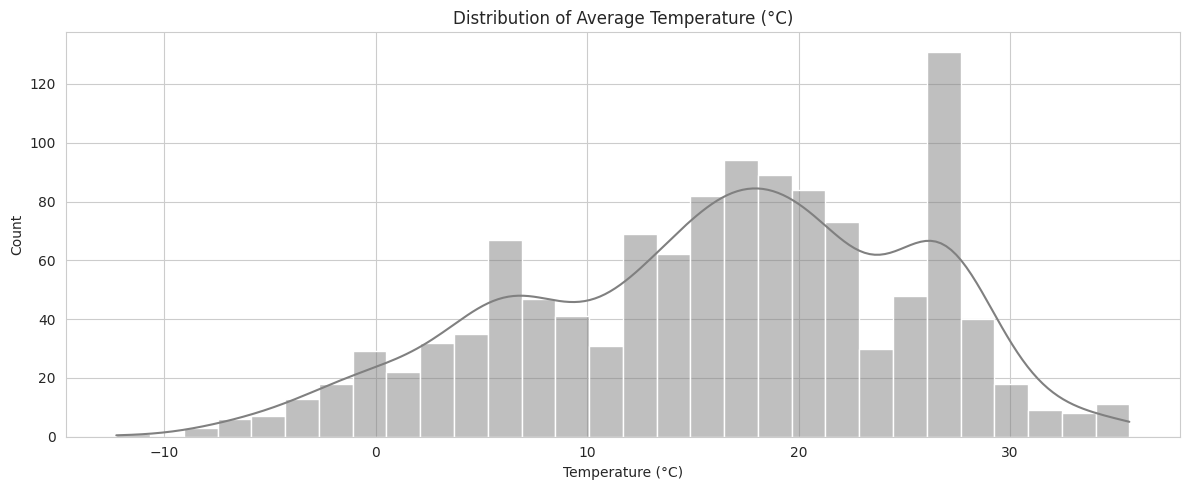

In [ ]:
#2. Distribution of Temperature
print("\n" + "=" * 50)
print("2. TEMPERATURE DISTRIBUTION")
print("=" * 50)
print(df["avg_temperature"].describe())

plt.figure(figsize=fig_size)
sns.histplot(df["avg_temperature"], bins=30, kde=True, color="gray")
plt.title("Distribution of Average Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.tight_layout()
plt.show()


3. CLOTHING CATEGORY DISTRIBUTION
clothing_category
Casual wear            415
Layered clothing       331
Light clothing         192
Heavy outerwear        186
Waterproof clothing     47
Thermal wear            29
Name: count, dtype: int64


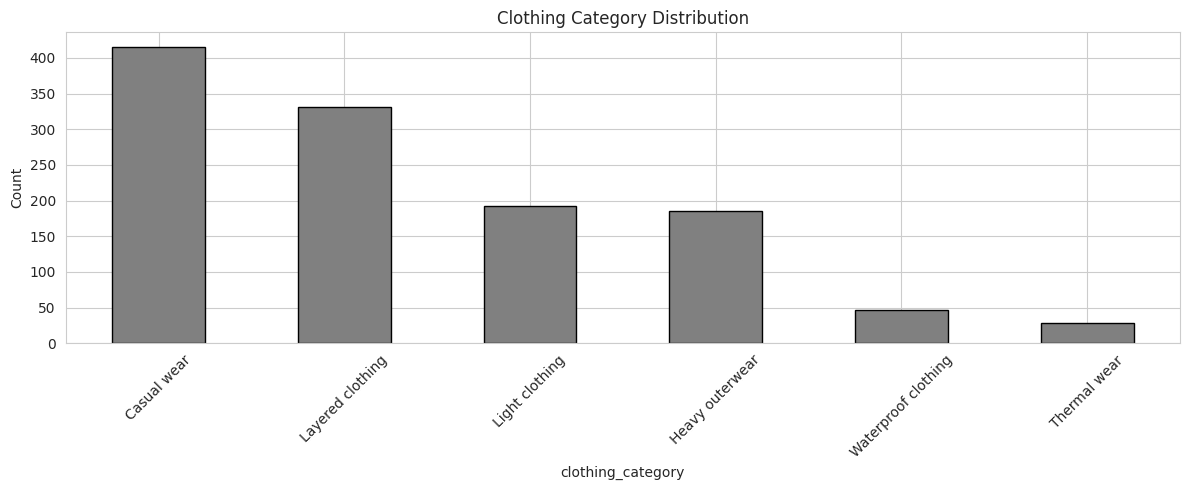

In [ ]:
#3. Clothing Category Distribution
print("\n" + "=" * 50)
print("3. CLOTHING CATEGORY DISTRIBUTION")
print("=" * 50)
print(df["clothing_category"].value_counts())

plt.figure(figsize=fig_size)
df["clothing_category"].value_counts().plot(kind="bar", color="gray", edgecolor="black")
plt.title("Clothing Category Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4. CORRELATION MATRIX
                     avg_temperature  avg_precipitation  avg_windspeed  \
avg_temperature                 1.00               0.26          -0.48   
avg_precipitation               0.26               1.00          -0.16   
avg_windspeed                  -0.48              -0.16           1.00   
avg_humidity                   -0.17               0.52           0.07   
avg_uv_index                     NaN                NaN            NaN   
avg_rating                     -0.34              -0.10           0.22   
review_count                    0.36              -0.05          -0.22   
review_demand_score             0.36              -0.05          -0.22   

                     avg_humidity  avg_uv_index  avg_rating  review_count  \
avg_temperature             -0.17           NaN       -0.34          0.36   
avg_precipitation            0.52           NaN       -0.10         -0.05   
avg_windspeed                0.07           NaN        0.22         -0.22   
av

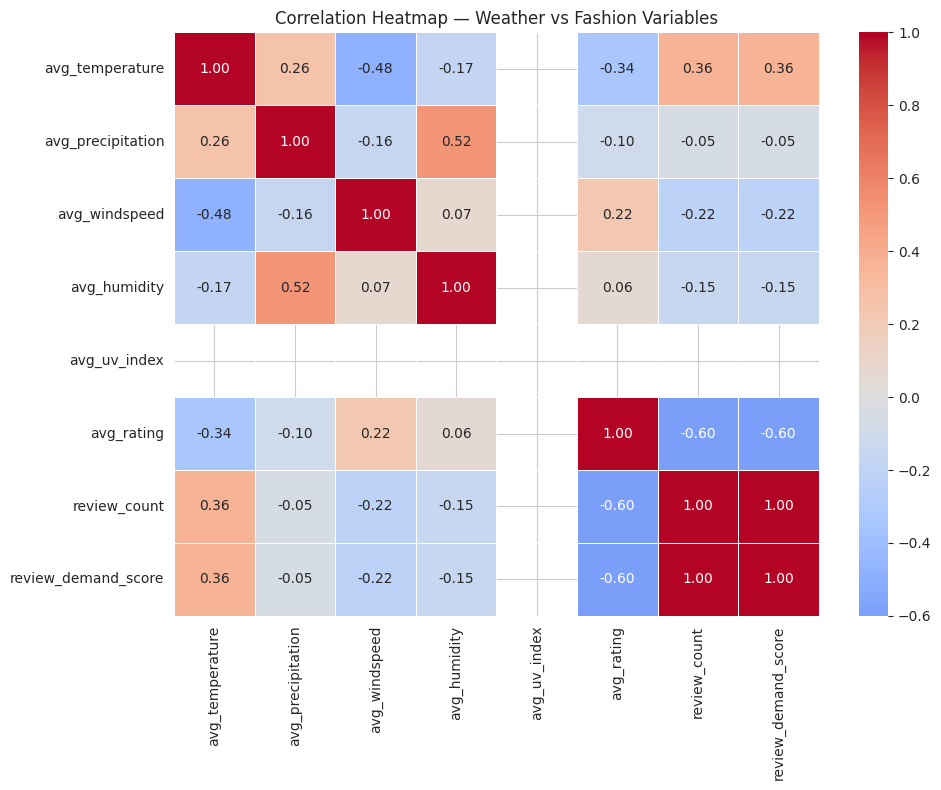

In [ ]:
# ── 4. Correlation Heatmap
print("\n" + "=" * 50)
print("4. CORRELATION MATRIX")
print("=" * 50)
numeric_cols = ["avg_temperature", "avg_precipitation", "avg_windspeed",
                "avg_humidity", "avg_uv_index", "avg_rating",
                "review_count", "review_demand_score"]
corr_matrix = df[numeric_cols].corr().round(2)
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Weather vs Fashion Variables")
plt.tight_layout()
plt.show()


5. TEMPERATURE vs CLOTHING CATEGORY


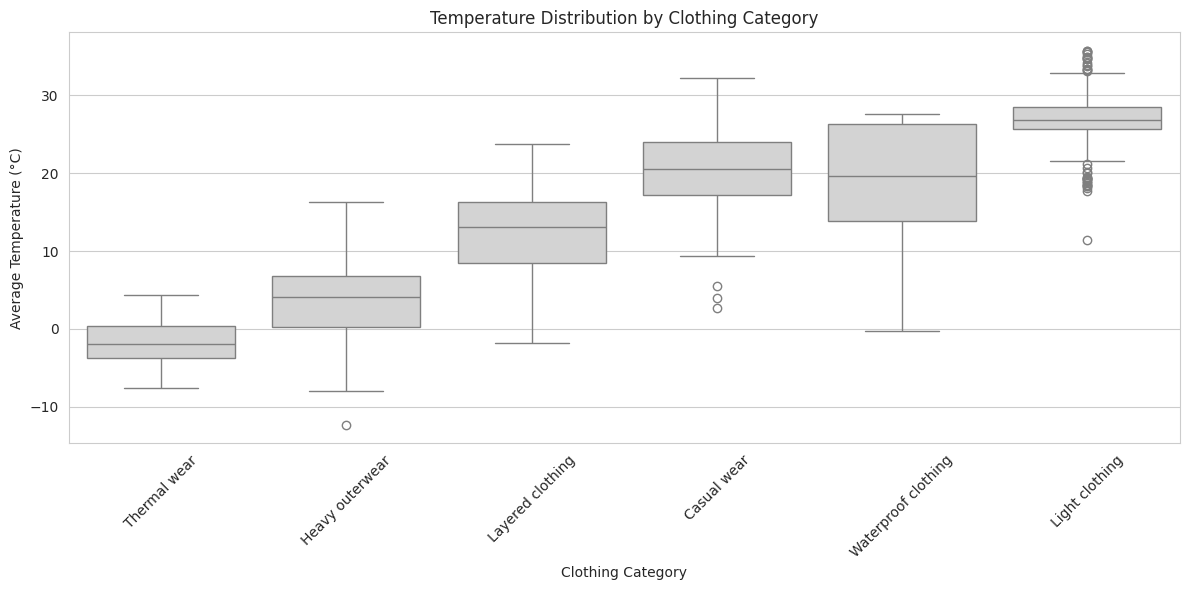

In [ ]:
print("\n" + "=" * 50)
print("5. TEMPERATURE vs CLOTHING CATEGORY")
print("=" * 50)
order = ["Thermal wear", "Heavy outerwear", "Layered clothing",
         "Casual wear", "Waterproof clothing", "UV-protective wear",
         "Light clothing"]
existing_order = [o for o in order if o in df["clothing_category"].unique()]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="clothing_category", y="avg_temperature",
            order=existing_order, color="lightgray")
plt.title("Temperature Distribution by Clothing Category")
plt.xlabel("Clothing Category")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



6. NORMALISATION — DEMAND SCORE
Before normalisation:
count     1020.000000
mean      2129.897059
std       3015.959458
min          2.000000
25%         44.500000
50%         88.000000
75%       5318.000000
max      11016.000000
Name: review_demand_raw, dtype: float64

After normalisation (0-1 scale):
count    1020.000000
mean        0.193199
std         0.273830
min         0.000000
25%         0.003859
50%         0.007808
75%         0.482658
max         1.000000
Name: review_demand_norm, dtype: float64


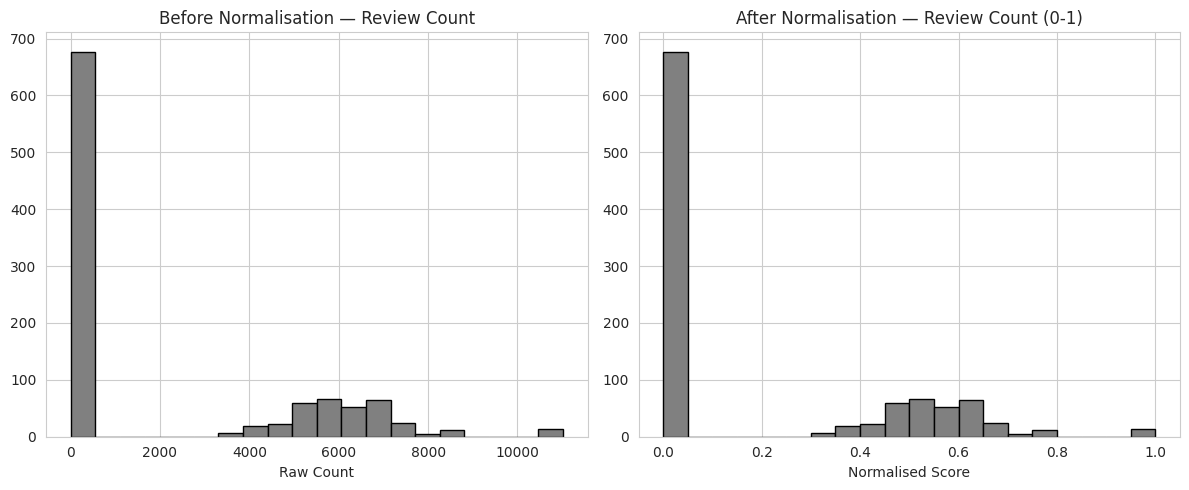

In [ ]:
#6. NORMALISATION — BEFORE AND AFTER
print("\n" + "=" * 50)
print("6. NORMALISATION — DEMAND SCORE")
print("=" * 50)
df["review_demand_raw"] = df["review_count"]
df["review_demand_norm"] = (
    (df["review_count"] - df["review_count"].min()) /
    (df["review_count"].max() - df["review_count"].min())
)

print("Before normalisation:")
print(df["review_demand_raw"].describe())
print("\nAfter normalisation (0-1 scale):")
print(df["review_demand_norm"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["review_demand_raw"].dropna(), bins=20,
             color="gray", edgecolor="black")
axes[0].set_title("Before Normalisation — Review Count")
axes[0].set_xlabel("Raw Count")
axes[1].hist(df["review_demand_norm"].dropna(), bins=20,
             color="gray", edgecolor="black")
axes[1].set_title("After Normalisation — Review Count (0-1)")
axes[1].set_xlabel("Normalised Score")
plt.tight_layout()
plt.show()



7. SEASONAL DEMAND PATTERNS
season_name
Autumn    2357.98
Spring    1441.60
Summer    2469.04
Winter    2282.84
Name: review_count, dtype: float64


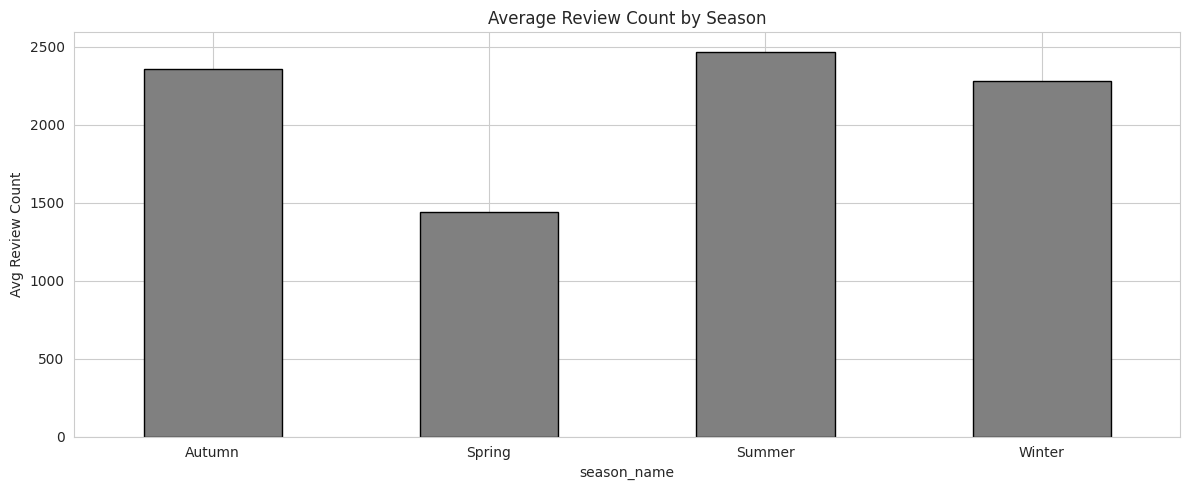


8. TEMPERATURE vs REVIEW DEMAND SCORE (Correlation)
Pearson Correlation: 0.3560


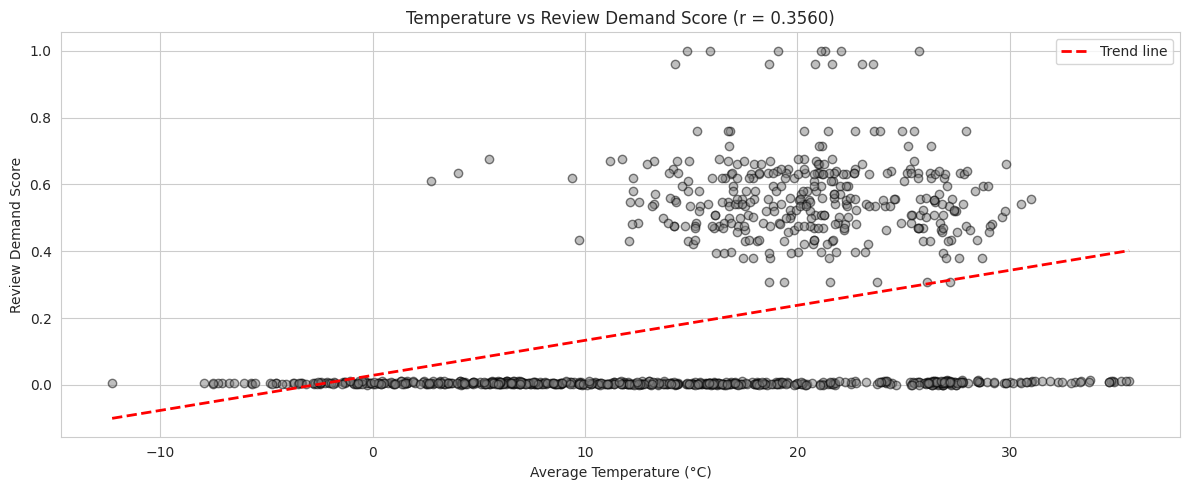


9. CITY COMPARISON
city
Moscow          6.499766
Stockholm       7.613907
Toronto         9.211487
Chicago        10.397792
Berlin         10.891762
Dublin         10.918148
London         11.389331
Seoul          11.724413
Paris          12.471460
New York       12.592507
Tokyo          15.660438
Cape Town      16.879666
Mexico City    17.135803
Sydney         17.354479
Sao Paulo      19.262315
Cairo          23.266475
Mumbai         26.605720
Singapore      26.673005
Jakarta        26.988450
Dubai          27.901555
Name: avg_temperature, dtype: float64


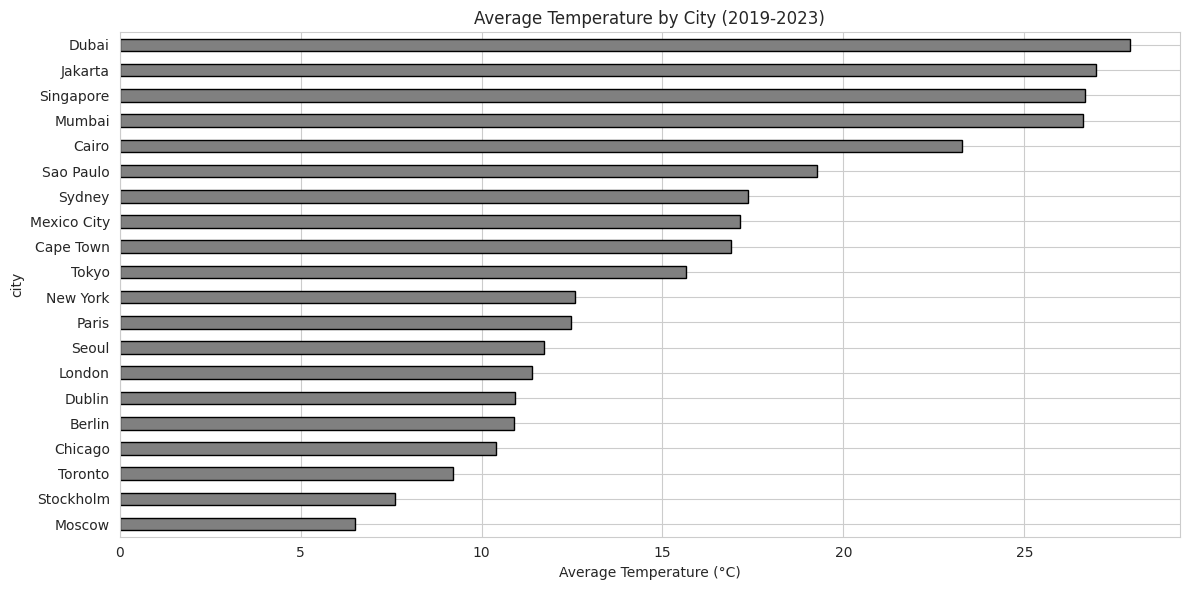


10. SUMMARY STATISTICS
       avg_temperature  avg_precipitation  avg_windspeed  avg_humidity  \
count          1200.00            1200.00        1200.00       1200.00   
mean             16.07               0.13          12.71         73.16   
std               9.16               0.15           3.54         10.94   
min             -12.28               0.00           4.83         34.28   
25%               9.27               0.04          10.36         67.07   
50%              17.07               0.09          12.66         74.94   
75%              22.73               0.17          14.96         81.13   
max              35.64               1.53          26.57         92.99   

       avg_uv_index  avg_rating  review_count  review_demand_score  
count           0.0     1020.00       1020.00              1020.00  
mean            NaN        4.46       2129.90                 0.19  
std             NaN        0.19       3015.96                 0.27  
min             NaN        3.40  

In [ ]:
#7. SEASONAL DEMAND PATTERNS
print("\n" + "=" * 50)
print("7. SEASONAL DEMAND PATTERNS")
print("=" * 50)
season_map = {0: "Spring", 1: "Summer", 2: "Autumn", 3: "Winter"}
df["season_name"] = df["season"].map(season_map)
seasonal = df.groupby("season_name")["review_count"].mean().round(2)
print(seasonal)

plt.figure(figsize=(12, 5))
seasonal.plot(kind="bar", color="gray", edgecolor="black")
plt.title("Average Review Count by Season")
plt.ylabel("Avg Review Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#8. TEMPERATURE vs REVIEW DEMAND SCORE

print("\n" + "=" * 50)
print("8. TEMPERATURE vs REVIEW DEMAND SCORE (Correlation)")
print("=" * 50)


temp_demand = df[["avg_temperature", "review_demand_score"]].dropna()
corr_val = temp_demand["avg_temperature"].corr(temp_demand["review_demand_score"])
print(f"Pearson Correlation: {corr_val:.4f}")

plt.figure(figsize=(12, 5))
plt.scatter(temp_demand["avg_temperature"], temp_demand["review_demand_score"],
            alpha=0.5, color="gray", edgecolor="black")
z = np.polyfit(temp_demand["avg_temperature"], temp_demand["review_demand_score"], 1)
p = np.poly1d(z)
x_line = np.linspace(temp_demand["avg_temperature"].min(),
                     temp_demand["avg_temperature"].max(), 100)
plt.plot(x_line, p(x_line), "r--", linewidth=2, label="Trend line")
plt.title(f"Temperature vs Review Demand Score (r = {corr_val:.4f})")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Review Demand Score")
plt.legend()
plt.tight_layout()
plt.show()

#9. CITY COMPARISON — AVG TEMPERATURE
print("\n" + "=" * 50)
print("9. CITY COMPARISON")
print("=" * 50)
city_temp = df.groupby("city")["avg_temperature"].mean().sort_values()
print(city_temp)

plt.figure(figsize=(12, 6))
city_temp.plot(kind="barh", color="gray", edgecolor="black")
plt.title("Average Temperature by City (2019-2023)")
plt.xlabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

#10. SUMMARY STATISTICS
print("\n" + "=" * 50)
print("10. SUMMARY STATISTICS")
print("=" * 50)
print(df[numeric_cols].describe().round(2))

print("\nEDA Complete.")